## Exploratory Data Analysis
to discover more interesting relationships in this dataset\


In [1]:
import json
from collections import Counter
from itertools import chain
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
DATA = Path("data/processed")

games = pd.read_parquet(DATA / "games_clean.parquet")
long = pd.concat([pd.read_parquet(DATA / f"{s}.parquet").assign(split=s) for s in ["train", "val", "test"]])
item2idx = json.loads((DATA / "item2idx.json").read_text())
idx2item = {i: t for t, i in item2idx.items()}



In [3]:
MIN_ITEM_COUNT = 5          # must match the cleaning notebook
UNK = "<unk>"
BAND_ORDER = ["<1200", "1200-1599", "1600-1999", "2000-2199", "2200+"]

In [5]:
train = games[games["split"] == "train"]
train_counts = Counter(chain.from_iterable(train["tokens"]))

count    18917.0
mean        61.1
std         33.1
min          3.0
25%         38.0
50%         56.0
75%         79.0
max        349.0
Name: n_plies, dtype: float64

per split:
        plies  sessions   unk
split                        
test   125572      1891   663
train  905713     15135  4680
val    124934      1891   717


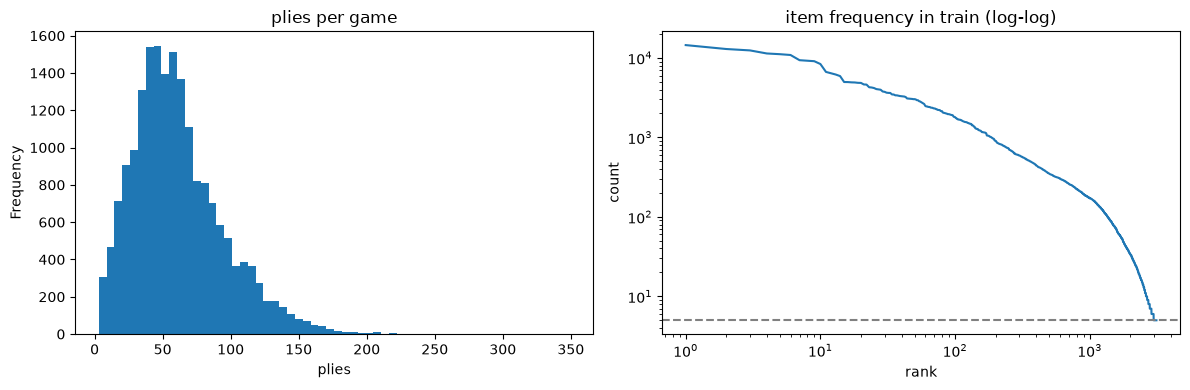

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
games["n_plies"].plot.hist(bins=60, ax=ax[0])
ax[0].set_title("plies per game")
ax[0].set_xlabel("plies")
counts = np.array(sorted((c for t, c in train_counts.items() if t != UNK), reverse=True))
ax[1].loglog(np.arange(1, len(counts) + 1), counts); ax[1].axhline(MIN_ITEM_COUNT, ls="--", c="grey")
ax[1].set_title("item frequency in train (log-log)")
ax[1].set_xlabel("rank")
ax[1].set_ylabel("count")

plt.tight_layout()

print(games["n_plies"].describe().round(1))
print("\nper split:"); print(long.groupby("split").agg(plies=("item_idx", "size"), sessions=("session_id", "nunique"),unk=("item_idx", lambda s: (s == 0).sum())))

1st-order Markov train-set HR@1 ceiling: 11.168%
in-book share of all plies: 7.9%  (median opening_ply = 4)


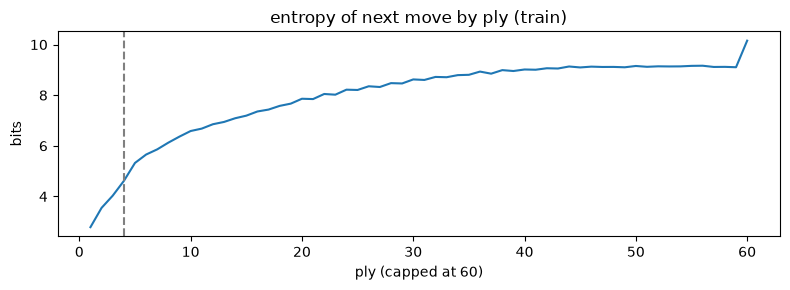

In [7]:
pairs, by_pos = Counter(), {}
for toks in train["tokens"]:
    for i in range(1, len(toks)):
        if toks[i] == UNK: continue
        pairs[(toks[i-1], toks[i])] += 1
        by_pos.setdefault(min(i, 60), Counter())[toks[i]] += 1

def entropy(counter):
    p = np.array(list(counter.values()), dtype=float); p /= p.sum()
    return float(-(p * np.log2(p)).sum())

ent = pd.Series({pos: entropy(c) for pos, c in sorted(by_pos.items())})
ent.plot(figsize=(8, 3), title="entropy of next move by ply (train)"); plt.xlabel("ply (capped at 60)"); plt.ylabel("bits")
plt.axvline(games["opening_ply"].median(), ls="--", c="grey"); plt.tight_layout()

succ = {}
for (a, b), c in pairs.items():
    succ.setdefault(a, Counter())[b] += c
hits = sum(max(c.values()) for c in succ.values())
print(f"1st-order Markov train-set HR@1 ceiling: {hits / sum(pairs.values()):.3%}")
print(f"in-book share of all plies: {long['in_book'].mean():.1%}  (median opening_ply = {games['opening_ply'].median():.0f})")

test games per rating band:
rating_band
<1200         33
1200-1599    747
1600-1999    915
2000-2199    147
2200+         49
Name: count, dtype: int64

test games with |rating_diff| < 200: 1451 of 1891


rating_diff,mismatched,balanced
rating_band,,
<1200,4,29
1200-1599,122,625
1600-1999,257,658
2000-2199,44,103
2200+,13,36


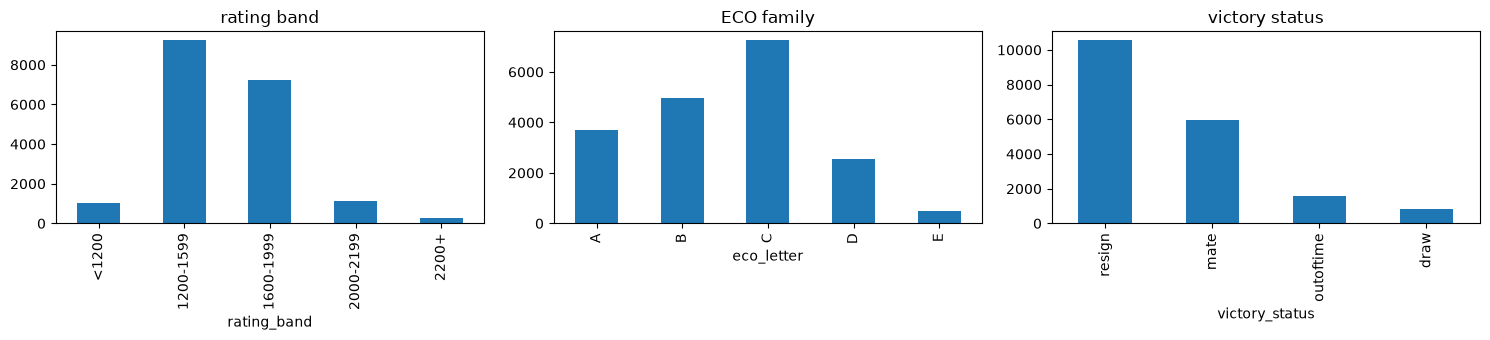

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
games["rating_band"].value_counts().reindex(BAND_ORDER).plot.bar(ax=ax[0], title="rating band")
games["eco_letter"].value_counts().sort_index().plot.bar(ax=ax[1], title="ECO family")
games["victory_status"].value_counts().plot.bar(ax=ax[2], title="victory status")
plt.tight_layout()

test = games[games["split"] == "test"]
print("test games per rating band:"); print(test["rating_band"].value_counts().reindex(BAND_ORDER))
print(f"\ntest games with |rating_diff| < 200: {(test['rating_diff'].abs() < 200).sum()} of {len(test)}")
pd.crosstab(test["rating_band"], test["rating_diff"].abs() < 200).reindex(BAND_ORDER).rename(columns={True: "balanced", False: "mismatched"})

In [11]:
dec = games[games["winner"] != "draw"].copy()
dec["white_won"] = dec["winner"] == "white"

first = dec.assign(first_move=dec["tokens"].str[0]).groupby("first_move")["white_won"].agg(["mean", "size"])
print("white win rate by first move (n >= 100):")
print(first[first["size"] >= 100].sort_values("mean", ascending=False).round(3))
print("\nwhite win rate by ECO family:")
print(dec.groupby("eco_letter")["white_won"].agg(["mean", "size"]).round(3))

white win rate by first move (n >= 100):
             mean   size
first_move              
w:c4        0.562    662
w:Nf3       0.560    607
w:e4        0.530  11347
w:d4        0.528   4119
w:b3        0.497    155
w:f4        0.478    138
w:g3        0.472    163
w:d3        0.364    110
w:e3        0.355    346

white win rate by ECO family:
             mean  size
eco_letter             
A           0.504  3511
B           0.515  4706
C           0.541  6931
D           0.528  2426
E           0.514   457
